# Assignment 1:

# Step 1 – Copper-Plate Market Clearing (Single Hour)

## Market-Clearing Mechanism

The market-clearing problem maximizes social welfare:

$$
\max \left(
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}
\right)
$$

subject to the power balance constraint:

$$
\sum_{i \in \mathcal{G}} p_{i,t}
+
\sum_{w \in \mathcal{W}} p_{w,t}
=
\sum_{d \in \mathcal{D}} d_{d,t}.
$$

The dual variable associated with the power balance constraint is the market-clearing price:

$$
\lambda_t.
$$

Under uniform pricing, all accepted generators and demands are settled at this price.

---

## Merit-Order Dispatch

Conventional generators are dispatched according to increasing marginal costs $C_i$.

The economic logic is:

- If $C_i < \lambda_t$ → the generator is **fully dispatched**.
- If $C_i = \lambda_t$ → the generator is **marginal** (partially dispatched).
- If $C_i > \lambda_t$ → the generator is **not dispatched**.

Renewable generators (wind) are modeled with zero marginal cost:

$$
C_w = 0,
$$

and are therefore dispatched up to their available capacity:

$$
0 \le p_{w,t} \le \bar{P}_{w,t}.
$$

---

## Welfare Decomposition

Social welfare is defined as:

$$
SW =
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}.
$$

Producer profit for generator $i$:

$$
\Pi_i = (\lambda_t - C_i) p_{i,t}.
$$

Demand utility for consumer $d$:

$$
\text{Utility}_d = d_{d,t}(U_d - \lambda_t).
$$

Infra-marginal generators earn positive profits, while the marginal generator earns zero profit.

---

## KKT Conditions and Price Formation

The stationarity condition for each generator is:

$$
C_i - \lambda_t + \mu_i^{\max} - \mu_i^{\min} = 0,
$$

where:

- $\mu_i^{\max}$ is the multiplier of the upper bound constraint,
- $\mu_i^{\min}$ is the multiplier of the lower bound constraint.

Three cases arise:

1. **Marginal unit:**  
   $p_{i,t} > 0$ and not at a bound  
   $$C_i = \lambda_t.$$

2. **Infra-marginal unit (capacity constrained):**  
   $p_{i,t} = P_i^{\max}$  
   $$C_i < \lambda_t.$$

3. **Rejected unit:**  
   $p_{i,t} = 0$  
   $$C_i > \lambda_t.$$

Thus, the market-clearing price equals the marginal accepted bid, confirming the economic interpretation of the dual variable $\lambda_t$.

In [25]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# ============================================
# SETS
# ============================================

G = range(12)         # i ∈ 𝒢 (conventional generators)
W = [1,2,3,4,5,6]     # w ∈ 𝒲 (single aggregated wind unit)
D_set = [0]           # d ∈ 𝒟 (single aggregated demand)

# ============================================
# PARAMETERS
# ============================================

# Generator parameters
P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Demand parameters
D_t = 2650.5          # total system demand
U_d = 100             # demand bid price

# ============================================
# WIND DATA IMPORT
# ============================================
wind_file = os.path.join("data", "processed", "wind_available_power_6_nodes_MW.csv")

wind_data = pd.read_csv(wind_file)

# Choose a specific hour (for example hour 18 peak denmand)
hour_star = 18

row = wind_data[wind_data["hour"] == hour_star]

P_w_bar = {
    1: row["wind_3"].values[0],
    2: row["wind_5"].values[0],
    3: row["wind_7"].values[0],
    4: row["wind_16"].values[0],
    5: row["wind_21"].values[0],
    6: row["wind_23"].values[0]
}
    
# ============================================
# REPORT INPUT SUMMARY
# ============================================

print("\n========== INPUT SUMMARY ==========")
print(f"Selected hour (wind peak): t = {hour_star}")
print(f"Total demand D_t: {D_t:.2f} MW")
print("\nWind availability per wind farm:")
for w in W:
    print(f"W{w}: {P_w_bar[w]:.2f} MW")

total_wind = sum(P_w_bar.values())
print(f"\nTotal wind availability: {total_wind:.2f} MW")
    
print(f"Demand bid U_d: {U_d:.2f} €/MWh")

total_capacity = sum(P_max[i] for i in G)
print(f"Total conventional capacity Σ P_i^max: {total_capacity:.2f} MW")



========== INPUT SUMMARY ==========
Selected hour (wind peak): t = 18
Total demand D_t: 2650.50 MW

Wind availability per wind farm:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW

Total wind availability: 385.81 MW
Demand bid U_d: 100.00 €/MWh
Total conventional capacity Σ P_i^max: 3375.00 MW


In [26]:
# ============================================
# MODEL
# ============================================

model = gp.Model("CopperPlate_Market")

# Decision variables
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

p_w = model.addVars(
    W,
    lb=0,
    ub=[P_w_bar[w] for w in W],
    name="p_w"
)

d_d = model.addVar(lb=0, ub=D_t, name="d_d")

# Objective: minimize (generation cost − utility)
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G)
    - U_d * d_d,
    GRB.MINIMIZE
)

# Power balance
balance = model.addConstr(
    gp.quicksum(p_i[i] for i in G) +
    gp.quicksum(p_w[w] for w in W)
    == d_d,
    name="power_balance"
)

model.optimize()



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 1 rows, 19 columns and 19 nonzeros (Min)
Model fingerprint: 0x571043cf
Model has 12 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+02]
  Bounds range     [3e+01, 3e+03]
  RHS range        [0e+00, 0e+00]

Presolve removed 0 rows and 9 columns
Presolve time: 0.01s
Presolved: 1 rows, 10 columns, 10 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.6505000e+05   2.455865e+02   0.000000e+00      0s
       1   -2.4752680e+05   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.01 seconds (0.00 work units)
Optimal objective -2.475268026e+05


In [27]:
# ============================================
# RESULTS
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== MARKET CLEARING RESULTS ==========\n")

    # Market-clearing price λ_t
    lambda_t = balance.Pi
    print(f"Market clearing price λ_t: {lambda_t:.2f} €/MWh")

    print("\nWind production:")

    for w in W:
        print(f"W{w}: {p_w[w].X:.2f} MW")

    print(f"Demand served d_d,t: {d_d.X:.2f} MW")

    # Total operating cost
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"\nTotal operating cost: {total_cost:.2f} €")

    # Social welfare
    social_welfare = U_d * d_d.X - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # Producer profits
    print("\nProducer profits Π_i:")
    for i in G:
        profit_i = lambda_t * p_i[i].X - C[i] * p_i[i].X
        print(f"Unit {i+1}: {profit_i:.2f} €")

    # Wind profit
    print("\nWind profits:")

    for w in W:
        wind_profit = lambda_t * p_w[w].X
        print(f"W{w}: {wind_profit:.2f} €")

    # Demand utility
    utility_d = d_d.X * (U_d - lambda_t)
    print(f"Demand utility: {utility_d:.2f} €")

    # ============================================
    # KKT CHECK
    # ============================================

    print("\n========== KKT CHECK ==========\n")

    for i in G:
        print(f"Unit {i+1}:")
        print(f"  p_i,t = {p_i[i].X:.2f}")
        print(f"  Reduced cost = {p_i[i].RC:.6f}")


========== MARKET CLEARING RESULTS ==========

Market clearing price λ_t: 13.32 €/MWh

Wind production:
W1: 56.85 MW
W2: 64.45 MW
W3: 84.63 MW
W4: 33.48 MW
W5: 65.02 MW
W6: 81.37 MW
Demand served d_d,t: 2650.50 MW

Total operating cost: 17523.20 €
Social welfare: 247526.80 €

Producer profits Π_i:
Unit 1: 0.00 €
Unit 2: 0.00 €
Unit 3: 0.00 €
Unit 4: 0.00 €
Unit 5: 0.00 €
Unit 6: 434.00 €
Unit 7: 434.00 €
Unit 8: 2920.00 €
Unit 9: 3140.00 €
Unit 10: 3996.00 €
Unit 11: 868.00 €
Unit 12: 850.50 €

Wind profits:
W1: 757.23 €
W2: 858.49 €
W3: 1127.30 €
W4: 446.01 €
W5: 866.07 €
W6: 1083.87 €
Demand utility: 229745.34 €

========== KKT CHECK ==========

Unit 1:
  p_i,t = 42.69
  Reduced cost = 0.000000
Unit 2:
  p_i,t = 152.00
  Reduced cost = 0.000000
Unit 3:
  p_i,t = 0.00
  Reduced cost = 7.380000
Unit 4:
  p_i,t = 0.00
  Reduced cost = 7.610000
Unit 5:
  p_i,t = 0.00
  Reduced cost = 12.790000
Unit 6:
  p_i,t = 155.00
  Reduced cost = -2.800000
Unit 7:
  p_i,t = 155.00
  Reduced cost = 

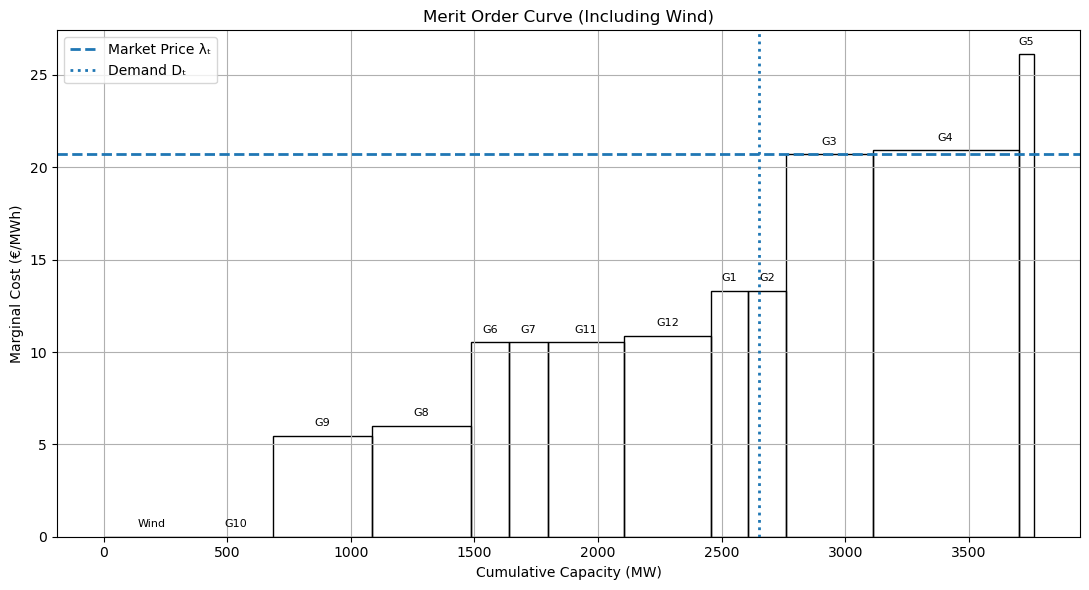

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# Generator Data
# -------------------------------

gen_data = pd.DataFrame({
    "unit": [f"G{i}" for i in range(1, 13)],
    "Pmax": [152, 152, 350, 591, 60, 155, 155, 400, 400, 300, 310, 350],
    "cost": [13.32, 13.32, 20.70, 20.93, 26.11, 10.52, 10.52,
             6.02, 5.47, 0.00, 10.52, 10.89]
})

# Wind block (from model)
P_w_bar_total = sum(P_w_bar.values())  # use your computed value
wind_block = pd.DataFrame({
    "unit": ["Wind"],
    "Pmax": [P_w_bar_total],
    "cost": [0.0]
})

# Combine wind + conventional
supply_data = pd.concat([wind_block, gen_data], ignore_index=True)

# Sort by marginal cost
supply_sorted = supply_data.sort_values("cost").reset_index(drop=True)

# Market price and demand
lambda_t = 20.70
D_t = 2650.5

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(11, 6))

cumulative_capacity = 0

for i in range(len(supply_sorted)):
    capacity = supply_sorted.loc[i, "Pmax"]
    cost = supply_sorted.loc[i, "cost"]
    label = supply_sorted.loc[i, "unit"]

    plt.bar(
        cumulative_capacity,
        cost,
        width=capacity,
        align='edge',
        edgecolor='black',
        fill=False
    )

    plt.text(
        cumulative_capacity + capacity/2,
        cost + 0.5,
        label,
        ha='center',
        fontsize=8
    )

    cumulative_capacity += capacity

# Market clearing price
plt.axhline(lambda_t, linestyle='--', linewidth=2, label="Market Price λₜ")

# Demand
plt.axvline(D_t, linestyle=':', linewidth=2, label="Demand Dₜ")

plt.xlabel("Cumulative Capacity (MW)")
plt.ylabel("Marginal Cost (€/MWh)")
plt.title("Merit Order Curve (Including Wind)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5 – Balancing Market

## Motivation

After the day-ahead market clears, real-time conditions may differ from the day-ahead schedule. 
Unexpected events can create an imbalance between realized generation and demand.

Two types of deviations are considered:

### Generator outage

One conventional generator unexpectedly fails. Therefore, its real-time production becomes:

$$
p_i^{real} = 0
$$

even though it may have been scheduled in the day-ahead market.

### Wind forecast errors

Wind generation may deviate from the day-ahead forecast.

We assume:

- Some wind farms produce **15% less** than their forecast.
- Some wind farms produce **10% more** than their forecast.

Thus:

$$
p_w^{real} =
\begin{cases}
0.85\,p_w^{DA} & \text{(underproduction)} \\
1.10\,p_w^{DA} & \text{(overproduction)}
\end{cases}
$$

---

## System imbalance

The imbalance between demand and realized generation is:

$$
\Delta =
D -
\left(
\sum_i p_i^{real}
+
\sum_w p_w^{real}
\right)
$$

Interpretation:

- $\Delta > 0$ → system **short** → **upward regulation required**
- $\Delta < 0$ → system **long** → **downward regulation required**

The balancing market is cleared to restore system balance.

In [29]:
# ============================================
# STEP 5 — REAL-TIME PRODUCTION
# ============================================

print("\n========== REAL-TIME DEVIATIONS ==========")

# Store day-ahead schedules
p_DA = {i: p_i[i].X for i in G}
p_w_DA = {w: p_w[w].X for w in W}
lambda_DA = lambda_t

# -----------------------------
# Generator outage
# -----------------------------

outage_unit = 11   # example: generator 12 fails

p_real = p_DA.copy()
p_real[outage_unit] = 0

print(f"\nGenerator outage at unit G{outage_unit+1}")
print("\nReal-time production of conventional generators:")
for i in G:
    print(f"G{i+1}: {p_real[i]:.2f} MW")


# -----------------------------
# Wind deviations
# -----------------------------

p_w_real = {}

for w in W:
    
    if w <= 3:
        # first half underproduces
        p_w_real[w] = 0.85 * p_w_DA[w]
    else:
        # second half overproduces
        p_w_real[w] = 1.10 * p_w_DA[w]

print("\nWind real-time production:")

for w in W:
    print(f"W{w}: DA={p_w_DA[w]:.2f} MW  |  Real={p_w_real[w]:.2f} MW")

# -----------------------------
# System imbalance
# -----------------------------

total_real_generation = sum(p_real.values()) + sum(p_w_real.values())

imbalance = D_t - total_real_generation

print("\n========== SYSTEM IMBALANCE ==========")
print(f"Total realized generation: {total_real_generation:.2f} MW")
print(f"Demand: {D_t:.2f} MW")
print(f"System imbalance Δ: {imbalance:.2f} MW")

if imbalance > 0:
    print("System is SHORT → upward regulation required")
else:
    print("System is LONG → downward regulation required")


========== REAL-TIME DEVIATIONS ==========

Generator outage at unit G12

Real-time production of conventional generators:
G1: 42.69 MW
G2: 152.00 MW
G3: 0.00 MW
G4: 0.00 MW
G5: 0.00 MW
G6: 155.00 MW
G7: 155.00 MW
G8: 400.00 MW
G9: 400.00 MW
G10: 300.00 MW
G11: 310.00 MW
G12: 0.00 MW

Wind real-time production:
W1: DA=56.85 MW  |  Real=48.32 MW
W2: DA=64.45 MW  |  Real=54.78 MW
W3: DA=84.63 MW  |  Real=71.94 MW
W4: DA=33.48 MW  |  Real=36.83 MW
W5: DA=65.02 MW  |  Real=71.52 MW
W6: DA=81.37 MW  |  Real=89.51 MW

========== SYSTEM IMBALANCE ==========
Total realized generation: 2287.60 MW
Demand: 2650.50 MW
System imbalance Δ: 362.90 MW
System is SHORT → upward regulation required


# Balancing Market Clearing

Once the system imbalance is identified, the Transmission System Operator (TSO) activates the balancing market to restore system balance.

Only a **subset of conventional generators** are assumed to provide balancing services.

## Balancing services

Two types of regulation are possible:

### Upward regulation

Generators increase their production above their day-ahead schedule.

The available upward regulation capacity is:

$$
0 \le r_i^{up} \le P_i^{max} - p_i^{DA}
$$

### Downward regulation

Generators reduce their production below their day-ahead schedule.

The available downward regulation capacity is:

$$
0 \le r_i^{down} \le p_i^{DA}
$$

---

## Balancing bids

Balancing offers are defined relative to the day-ahead price.

### Upward regulation price

$$
C_i^{up} = \lambda^{DA} + 0.10 C_i
$$

### Downward regulation price

$$
C_i^{down} = \lambda^{DA} - 0.15 C_i
$$

---

## Load curtailment

If regulation capacity is insufficient, the TSO can curtail load at a penalty cost:

$$
C^{shed} = 500 \text{ €/MWh}
$$

---

## Balancing optimization problem

The TSO minimizes the cost of balancing actions:

$$
\min
\sum_i C_i^{up} r_i^{up}
+
\sum_i C_i^{down} r_i^{down}
+
500 \cdot L
$$

subject to the balancing constraint:

$$
\sum_i r_i^{up}
-
\sum_i r_i^{down}
+
L
=
\Delta
$$

The dual variable of this constraint represents the **balancing price**:

$$
\lambda^{BAL}
$$

In [30]:
# ============================================
# BALANCING MARKET OPTIMIZATION
# ============================================

print("\n========== BALANCING MARKET CLEARING ==========")

# -----------------------------------
# Flexible generators able to provide balancing
# (example subset)
# -----------------------------------

flexible_generators = [1,2,3,4,5,6]

# -----------------------------------
# Balancing bid prices
# -----------------------------------

C_up = {i: lambda_DA + 0.10 * C[i] for i in flexible_generators}
C_down = {i: lambda_DA - 0.15 * C[i] for i in flexible_generators}

# -----------------------------------
# Model
# -----------------------------------

bal_model = gp.Model("BalancingMarket")

# Variables

r_up = bal_model.addVars(
    flexible_generators,
    lb=0,
    name="r_up"
)

r_down = bal_model.addVars(
    flexible_generators,
    lb=0,
    name="r_down"
)

load_shed = bal_model.addVar(lb=0, name="load_shed")

# -----------------------------------
# Objective
# -----------------------------------

bal_model.setObjective(

    gp.quicksum(C_up[i] * r_up[i] for i in flexible_generators)
    +
    gp.quicksum(C_down[i] * r_down[i] for i in flexible_generators)
    +
    500 * load_shed,

    GRB.MINIMIZE
)

# -----------------------------------
# Capacity limits
# -----------------------------------

for i in flexible_generators:

    bal_model.addConstr(
        r_up[i] <= P_max[i] - p_DA[i],
        name=f"up_cap_{i}"
    )

    bal_model.addConstr(
        r_down[i] <= p_DA[i],
        name=f"down_cap_{i}"
    )

# -----------------------------------
# Balancing constraint
# -----------------------------------

balancing_constraint = bal_model.addConstr(

    gp.quicksum(r_up[i] for i in flexible_generators)
    -
    gp.quicksum(r_down[i] for i in flexible_generators)
    +
    load_shed

    == imbalance,

    name="system_balance"
)

bal_model.optimize()

# -----------------------------------
# Results
# -----------------------------------

lambda_BAL = balancing_constraint.Pi

print("\nBalancing price λ_BAL:", round(lambda_BAL,2), "€/MWh")

print("\nUpward regulation:")

for i in flexible_generators:
    print(f"G{i+1}: {r_up[i].X:.2f} MW")

print("\nDownward regulation:")

for i in flexible_generators:
    print(f"G{i+1}: {r_down[i].X:.2f} MW")

print("\nLoad curtailment:", load_shed.X)


========== BALANCING MARKET CLEARING ==========
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.5.0 24F74)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 13 rows, 13 columns and 25 nonzeros (Min)
Model fingerprint: 0x345db094
Model has 13 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 5e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 6e+02]

Presolve removed 12 rows and 7 columns
Presolve time: 0.00s
Presolved: 1 rows, 6 columns, 6 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   4.536279e+01   0.000000e+00      0s
       1    8.2635821e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.00 seconds (0.00 work units)
Optimal objective  8.263582124e+03

Balancing price λ_BAL: 22.79 €/MWh

Upward regulation:
G2: 0.00 MW
G3: 350.00 M

## Balancing Market Merit Order

To better understand how the balancing market clears, we construct the **balancing merit order curve**.

The balancing market clears by activating the least-cost regulation bids until the system imbalance is resolved.

The **balancing price** is determined by the marginal regulation bid, analogous to the merit-order principle in the day-ahead market.

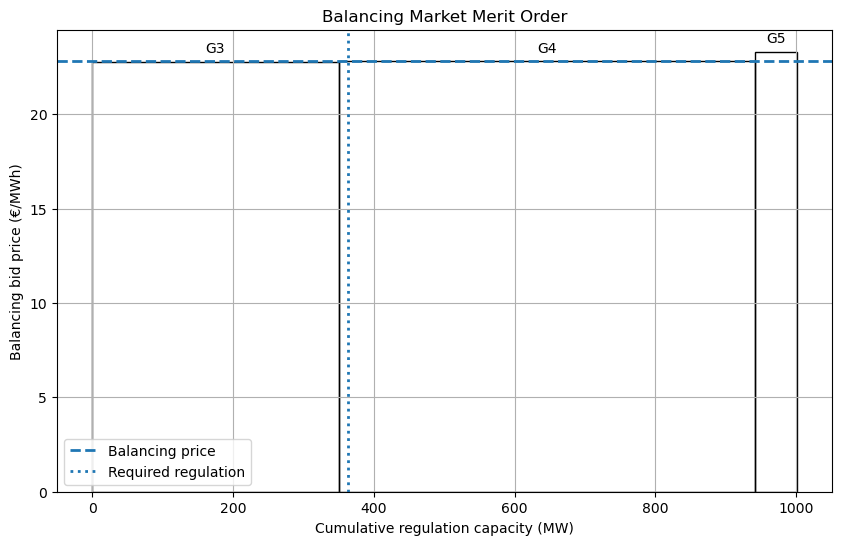

In [31]:
# ============================================
# BALANCING MERIT ORDER PLOT
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

balancing_data = []

for i in flexible_generators:
    
    up_capacity = P_max[i] - p_DA[i]
    
    if up_capacity > 0:
        balancing_data.append({
            "unit": f"G{i+1}",
            "capacity": up_capacity,
            "price": C_up[i]
        })

bal_df = pd.DataFrame(balancing_data)

# sort by balancing bid
bal_df = bal_df.sort_values("price")

plt.figure(figsize=(10,6))

cum_cap = 0

for _, row in bal_df.iterrows():
    
    plt.bar(
        cum_cap,
        row["price"],
        width=row["capacity"],
        align="edge",
        edgecolor="black",
        fill=False
    )
    
    plt.text(
        cum_cap + row["capacity"]/2,
        row["price"] + 0.5,
        row["unit"],
        ha="center"
    )
    
    cum_cap += row["capacity"]

# balancing price
plt.axhline(lambda_BAL, linestyle="--", linewidth=2, label="Balancing price")

# imbalance
plt.axvline(abs(imbalance), linestyle=":", linewidth=2, label="Required regulation")

plt.xlabel("Cumulative regulation capacity (MW)")
plt.ylabel("Balancing bid price (€/MWh)")
plt.title("Balancing Market Merit Order")
plt.legend()
plt.grid(True)

plt.show()

# Profit Calculation Under Different Settlement Rules

The total profit of each market participant consists of two components:

1. **Day-ahead market profit**
2. **Balancing market settlement**

We compare two imbalance settlement schemes:

---

## One-price scheme

All deviations are settled at the **balancing price**.

Profit for generator $i$:

$$
\Pi_i =
\lambda^{DA} p_i^{DA}
+
\lambda^{BAL}(p_i^{real} - p_i^{DA})
-
C_i p_i^{real}
$$

---

## Two-price scheme

Balancing service providers are paid the **balancing price**, while participants causing imbalance are settled at the **day-ahead price**.

This mechanism penalizes forecasting errors and encourages accurate scheduling.

In [32]:
# ============================================
# PROFIT DATAFRAMES
# ============================================

import pandas as pd

rows_one = []
rows_two = []

# ============================================
# CONVENTIONAL GENERATORS
# ============================================

for i in G:

    up = r_up[i].X if i in flexible_generators else 0
    down = r_down[i].X if i in flexible_generators else 0

    p_real_total = p_real[i] + up - down

    DA_revenue = lambda_DA * p_DA[i]
    imbalance = p_real_total - p_DA[i]

    # ----------------------
    # ONE PRICE
    # ----------------------

    balancing_rev_one = lambda_BAL * imbalance
    operational_cost = C[i] * p_real_total

    profit_one = DA_revenue + balancing_rev_one - operational_cost

    rows_one.append({
        "Unit": f"G{i+1}",
        "Type": "Generator",
        "DA_Revenue": DA_revenue,
        "Balancing_Revenue": balancing_rev_one,
        "Operational_Cost": operational_cost,
        "Profit": profit_one
    })

    # ----------------------
    # TWO PRICE
    # ----------------------

    if imbalance > 0:
        settlement_price = lambda_BAL
    else:
        settlement_price = lambda_DA

    balancing_rev_two = settlement_price * imbalance
    profit_two = DA_revenue + balancing_rev_two - operational_cost

    rows_two.append({
        "Unit": f"G{i+1}",
        "Type": "Generator",
        "DA_Revenue": DA_revenue,
        "Balancing_Revenue": balancing_rev_two,
        "Operational_Cost": operational_cost,
        "Profit": profit_two
    })


# ============================================
# WIND FARMS
# ============================================

for w in W:

    DA_revenue = lambda_DA * p_w_DA[w]
    imbalance = p_w_real[w] - p_w_DA[w]

    operational_cost = 0

    # ----------------------
    # ONE PRICE
    # ----------------------

    balancing_rev_one = lambda_BAL * imbalance
    profit_one = DA_revenue + balancing_rev_one

    rows_one.append({
        "Unit": f"W{w}",
        "Type": "Wind",
        "DA_Revenue": DA_revenue,
        "Balancing_Revenue": balancing_rev_one,
        "Operational_Cost": operational_cost,
        "Profit": profit_one
    })

    # ----------------------
    # TWO PRICE
    # ----------------------

    balancing_rev_two = lambda_DA * imbalance
    profit_two = DA_revenue + balancing_rev_two

    rows_two.append({
        "Unit": f"W{w}",
        "Type": "Wind",
        "DA_Revenue": DA_revenue,
        "Balancing_Revenue": balancing_rev_two,
        "Operational_Cost": operational_cost,
        "Profit": profit_two
    })


# ============================================
# DATAFRAMES
# ============================================

df_one_price = pd.DataFrame(rows_one)
df_two_price = pd.DataFrame(rows_two)

print("\n========== ONE PRICE SCHEME ==========")
display(df_one_price.round(2))

print("\n========== TWO PRICE SCHEME ==========")
display(df_two_price.round(2))


========== ONE PRICE SCHEME ==========


,Unit,Type,DA_Revenue,Balancing_Revenue,Operational_Cost,Profit
0,G1,Generator,883.72,0.00,568.66,315.07
1,G2,Generator,3146.40,0.00,2024.64,1121.76
2,G3,Generator,0.00,7977.55,7245.00,732.55
3,G4,Generator,0.00,294.08,270.05,24.04
4,G5,Generator,0.00,0.00,0.00,0.00
5,G6,Generator,3208.50,0.00,1630.60,1577.90
6,G7,Generator,3208.50,0.00,1630.60,1577.90
7,G8,Generator,8280.00,0.00,2408.00,5872.00
8,G9,Generator,8280.00,0.00,2188.00,6092.00
9,G10,Generator,6210.00,0.00,0.00,6210.00



========== TWO PRICE SCHEME ==========


,Unit,Type,DA_Revenue,Balancing_Revenue,Operational_Cost,Profit
0,G1,Generator,883.72,0.00,568.66,315.07
1,G2,Generator,3146.40,0.00,2024.64,1121.76
2,G3,Generator,0.00,7977.55,7245.00,732.55
3,G4,Generator,0.00,294.08,270.05,24.04
4,G5,Generator,0.00,0.00,0.00,0.00
5,G6,Generator,3208.50,0.00,1630.60,1577.90
6,G7,Generator,3208.50,0.00,1630.60,1577.90
7,G8,Generator,8280.00,0.00,2408.00,5872.00
8,G9,Generator,8280.00,0.00,2188.00,6092.00
9,G10,Generator,6210.00,0.00,0.00,6210.00
